# SDE-Net paper-faithful no-PV-lag — evento sahariano di aprile 2019

Analisi post-hoc del modello già addestrato. Il notebook **non rilancia il training** e usa tutte le predizioni disponibili, senza campionamento.

Evento esterno di riferimento: grande intrusione di polvere sahariana iniziata il 21 aprile 2019, osservata da NASA/MODIS sull'Europa il 23 aprile e fino alle Alpi il 25 aprile: https://modis.gsfc.nasa.gov/gallery/individual.php?db_date=2019-04-26

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if not (ROOT / 'physiq_pv').is_dir():
    raise FileNotFoundError('Avviare il notebook dalla root del repository o da notebooks/.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import physiq_pv.reporting.posthoc_outputs as posthoc_outputs
import physiq_pv.experiments.sde_pipeline as pipe

importlib.reload(posthoc_outputs)
pipe = importlib.reload(pipe)

RUN_NAME = 'pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1'
out_dir = ROOT / 'outputs' / RUN_NAME
predictions_path = out_dir / 'predictions.csv'
pvgis_2019_path = Path('/data/SentinelPV/pvgis_data/data/pvgis_summed_irradiance/piedmont_pvgis_2019.nc')

for required in (
    predictions_path,
    out_dir / 'reference_production_peaks.csv',
    pvgis_2019_path,
):
    if not required.is_file():
        raise FileNotFoundError(required)

print('Run SDE-Net:', out_dir)
print('Predizioni:', predictions_path)
print('PVGIS 2019:', pvgis_2019_path)

Run SDE-Net: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1
Predizioni: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1/predictions.csv
PVGIS 2019: /data/SentinelPV/pvgis_data/data/pvgis_summed_irradiance/piedmont_pvgis_2019.nc


## 1. Evidenza fisica nei PVGIS

La POA viene ricostruita nello stesso modo della pipeline: `direct_irradiance_tilted + diffuse_irradiance_tilted`. Il campo `solar_irradiance_poa` originale non viene utilizzato.

,poa_kwh_m2,direct_kwh_m2,diffuse_kwh_m2,diffuse_fraction,poa_spatial_std_kwh_m2,temperature_daylight_mean,pv_kwh_mean
date,,,,,,,
2019-04-18,5.089963,2.822098,2.267865,0.607964,1.514998,11.770125,4.043807
2019-04-19,5.783127,3.620821,2.162306,0.513750,1.278743,11.995184,4.612193
2019-04-20,6.214971,4.043653,2.171318,0.490171,0.726499,12.553519,4.954783
2019-04-21,4.292643,1.487123,2.805520,0.789261,0.993247,12.909733,3.406193
2019-04-22,3.796652,1.253900,2.542753,0.829280,0.704398,11.935122,3.040941
2019-04-23,1.431799,0.035702,1.396097,0.988132,0.459415,8.630886,1.062804
2019-04-24,2.183595,0.547293,1.636302,0.895973,0.969093,9.789631,1.683311
2019-04-25,2.341776,0.287651,2.054125,0.930731,0.883413,9.610726,1.810506
2019-04-26,4.348282,2.387226,1.961055,0.724430,1.104465,11.169335,3.442231


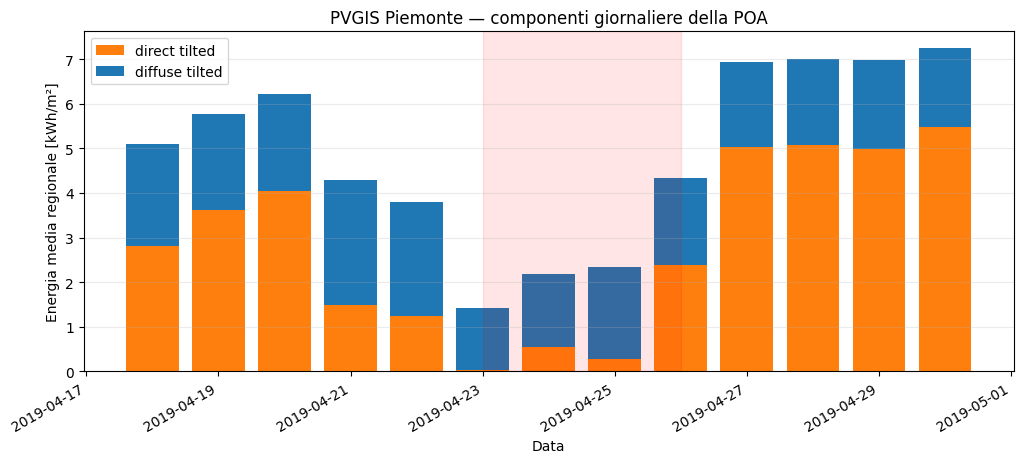

Grafico: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1/figures/april_dust_event/april_irradiance_components.png


In [2]:
variables = [
    'direct_irradiance_tilted',
    'diffuse_irradiance_tilted',
    'temperature_2m',
    'wind_speed_10m',
    'pv_power_output',
]
with xr.open_dataset(pvgis_2019_path) as dataset:
    april = dataset[variables].sel(
        time=slice('2019-04-18', '2019-04-30T23:59:59')
    ).load()

timestamps = pd.to_datetime(april.time.values)
dates = pd.Index(timestamps.date)
physical_rows = []
for date in dates.unique():
    mask = dates == date
    direct = april.direct_irradiance_tilted.values[:, mask]
    diffuse = april.diffuse_irradiance_tilted.values[:, mask]
    poa = direct + diffuse
    daylight = poa > 10.0
    node_energy = poa.sum(axis=1) / 1000.0
    physical_rows.append({
        'date': pd.Timestamp(date),
        'poa_kwh_m2': float(node_energy.mean()),
        'direct_kwh_m2': float(direct.sum(axis=1).mean() / 1000.0),
        'diffuse_kwh_m2': float(diffuse.sum(axis=1).mean() / 1000.0),
        'diffuse_fraction': float((diffuse[daylight] / poa[daylight]).mean()),
        'poa_spatial_std_kwh_m2': float(node_energy.std()),
        'temperature_daylight_mean': float(
            april.temperature_2m.values[:, mask][daylight].mean()
        ),
        'pv_kwh_mean': float(
            april.pv_power_output.values[:, mask].sum(axis=1).mean() / 1000.0
        ),
    })

physical = pd.DataFrame(physical_rows).set_index('date')
display(physical)

physical_figure_dir = out_dir / 'figures' / 'april_dust_event'
physical_figure_dir.mkdir(parents=True, exist_ok=True)
physical_figure_path = physical_figure_dir / 'april_irradiance_components.png'

fig, axis = plt.subplots(figsize=(12, 5))
axis.bar(
    physical.index,
    physical['direct_kwh_m2'],
    label='direct tilted',
    color='tab:orange',
)
axis.bar(
    physical.index,
    physical['diffuse_kwh_m2'],
    bottom=physical['direct_kwh_m2'],
    label='diffuse tilted',
    color='tab:blue',
)
axis.axvspan(pd.Timestamp('2019-04-23'), pd.Timestamp('2019-04-26'), color='red', alpha=0.10)
axis.set(
    title='PVGIS Piemonte — componenti giornaliere della POA',
    ylabel='Energia media regionale [kWh/m²]',
    xlabel='Data',
)
axis.legend()
axis.grid(axis='y', alpha=0.25)
fig.autofmt_xdate()
fig.savefig(physical_figure_path, dpi=140, bbox_inches='tight')
plt.show()
print('Grafico:', physical_figure_path)

## 2. Risposta temporale di SDE-Net

La finestra 21–27 aprile include l'ingresso nell'evento, i giorni più severi e il ritorno alla normalità. La diagnostica usa tutte le 1.149 località e mostra previsione, errore, copertura, frazione regionale MTGFlow e componenti di incertezza.

Righe usate (nessun campionamento): 193,032
Soglia regionale MAM: 0.33855526544821585


,scope,count,locations,timestamps,mae,rmse,picp,mpiw,rare_timestamp_count,mean_y_std,mean_epistemic_std,mean_aleatoric_std
0,all_event_hours,193032,1149,168,34.297317,68.222664,0.972834,172.476028,80,43.999794,0.009976,43.999791
1,daytime,102967,1149,93,63.931807,93.383614,0.949935,319.896246,41,81.607683,0.018643,81.607677
2,regional_rare_hours,91920,1149,80,28.475326,58.065639,0.980124,157.389715,80,40.151175,0.003708,40.151175


,timestamp,n_rows,mean_y_true,mean_y_pred,mean_lower_pi,mean_upper_pi,mae,picp,mpiw,is_rare,mean_y_std,mean_event_score,mean_solar,mean_epistemic_std,mean_aleatoric_std,rmse,regional_anomaly_fraction
0,2019-04-21 00:10:00,1149,0.0,8.303193e-09,-1.396596,1.396596,8.303193e-09,1.0,2.793192,False,0.712562,0.298201,0.0,1.071453e-12,0.712562,1.113972e-08,0.100957
1,2019-04-21 01:10:00,1149,0.0,7.639950e-09,-1.396596,1.396596,7.639950e-09,1.0,2.793192,False,0.712562,0.357326,0.0,1.048705e-12,0.712562,1.091279e-08,0.120975
2,2019-04-21 02:10:00,1149,0.0,1.014595e-08,-1.396596,1.396596,1.014595e-08,1.0,2.793192,False,0.712562,0.406170,0.0,1.163906e-12,0.712562,1.629355e-08,0.137511
3,2019-04-21 03:10:00,1149,0.0,4.677694e-08,-1.396596,1.396596,4.677694e-08,1.0,2.793192,False,0.712562,0.318766,0.0,4.253419e-12,0.712562,8.450795e-08,0.107920
4,2019-04-21 04:10:00,1149,0.0,3.142557e-05,-1.396567,1.396629,3.142557e-05,1.0,2.793196,False,0.712563,0.313625,0.0,1.407727e-09,0.712563,4.587833e-05,0.106179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,2019-04-27 19:10:00,1149,0.0,3.239030e-06,-1.396593,1.396599,3.239030e-06,1.0,2.793192,False,0.712562,0.190231,0.0,2.569751e-10,0.712562,4.874142e-06,0.064404
164,2019-04-27 20:10:00,1149,0.0,2.211847e-07,-1.396596,1.396596,2.211847e-07,1.0,2.793192,False,0.712562,0.110540,0.0,1.853890e-11,0.712562,4.173227e-07,0.037424
165,2019-04-27 21:10:00,1149,0.0,4.855999e-08,-1.396596,1.396596,4.855999e-08,1.0,2.793192,False,0.712562,0.125964,0.0,5.433476e-12,0.712562,8.289444e-08,0.042646
166,2019-04-27 22:10:00,1149,0.0,2.075536e-08,-1.396596,1.396596,2.075536e-08,1.0,2.793192,False,0.712562,0.125964,0.0,2.735055e-12,0.712562,3.449810e-08,0.042646


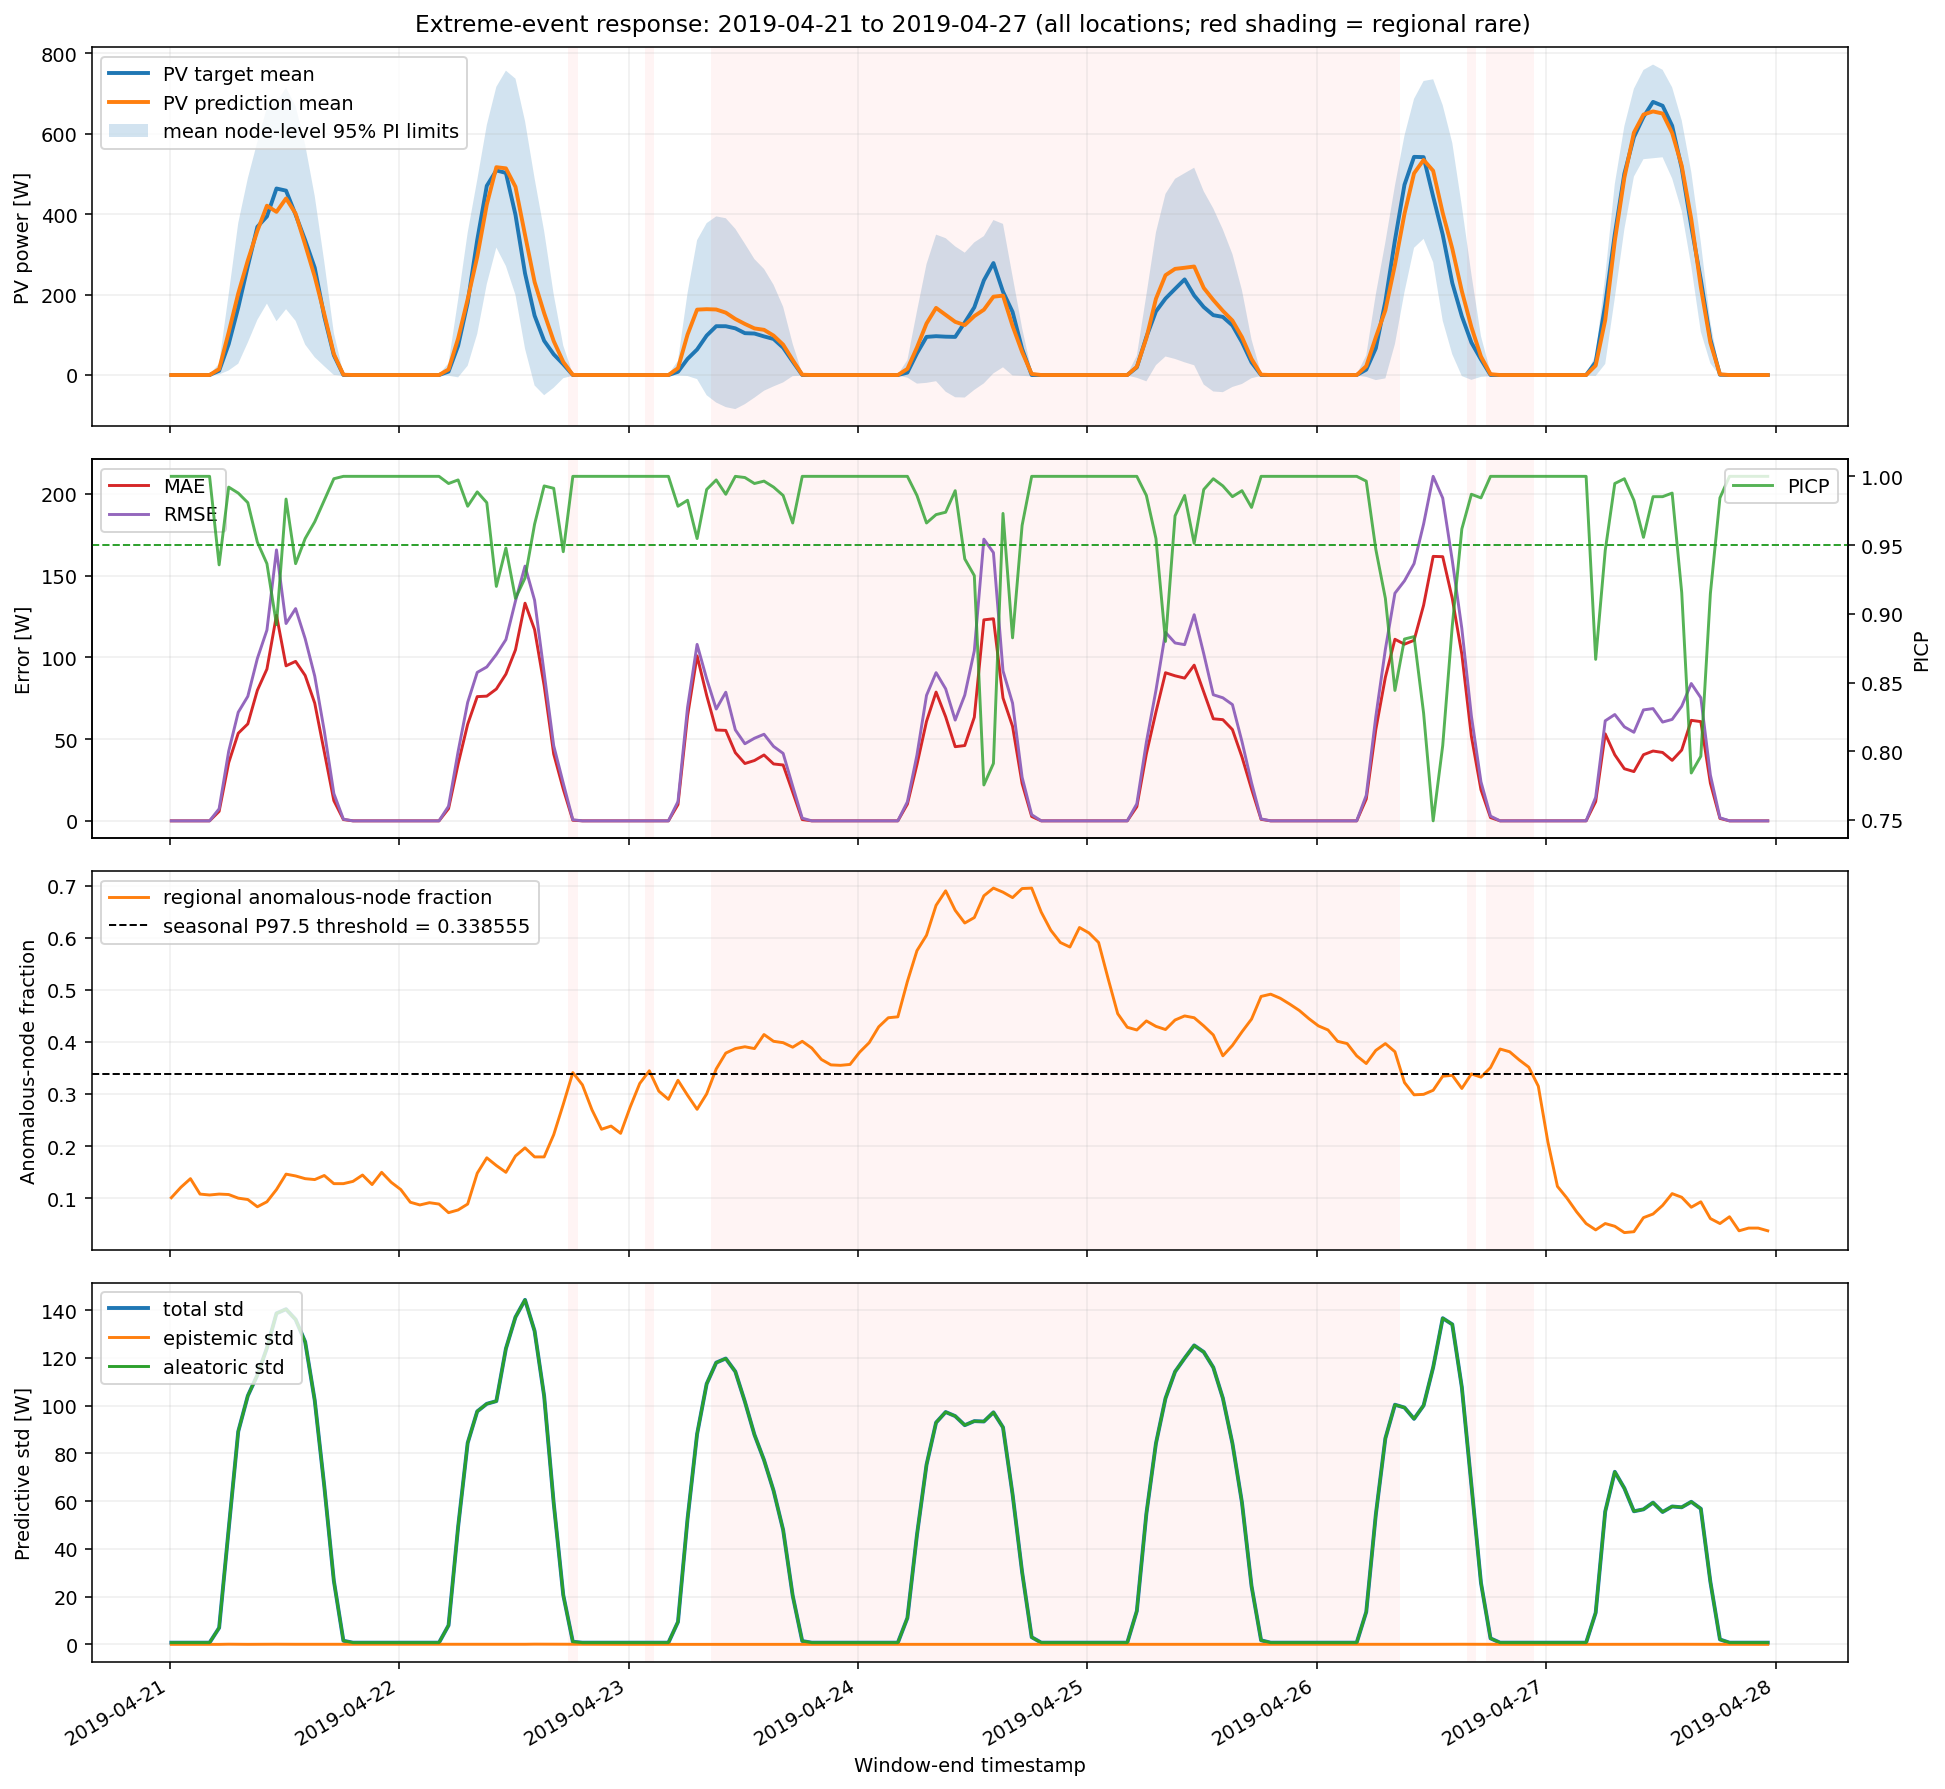

CSV orario: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1/extreme_event_20190421_20190427_hourly.csv
CSV riepilogo: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1/extreme_event_20190421_20190427_summary.csv


In [3]:
april_event = pipe.build_extreme_event_diagnostic(
    str(out_dir),
    start='2019-04-21',
    end='2019-04-28',
    figure_subdir='april_dust_event',
)

print(f"Righe usate (nessun campionamento): {april_event['rows_used']:,}")
print('Soglia regionale MAM:', april_event['regional_threshold'])
display(april_event['summary'])
display(april_event['hourly'])
display(Image(filename=str(april_event['figure_path'])))
print('CSV orario:', april_event['hourly_path'])
print('CSV riepilogo:', april_event['summary_path'])

## 3. Normale 2019 vs 23, 24, 25 e 26 aprile

Il confronto usa esclusivamente righe diurne valide, tutte le località e nessun campionamento. Le categorie sono separate nelle fasce 0–20%, 20–40%, 40–60%, 60–80% e 80–100% della potenza di riferimento. Il 26 aprile è mantenuto separato per osservare il possibile trascinamento della finestra MTGFlow.

,bin,category,count,mae,rmse,mpiw,nmpil,picp,clc
0,daytime_0_20_pct,normal_2019,1845599,37.400770,64.058534,174.098542,0.195208,0.954714,0.382308
1,daytime_0_20_pct,2019-04-23,12916,44.905148,59.343464,295.938443,0.331822,0.989703,0.563946
2,daytime_0_20_pct,2019-04-24,10602,43.485266,59.555474,273.273251,0.306408,0.984814,0.530396
3,daytime_0_20_pct,2019-04-25,9200,53.238868,75.270687,280.470194,0.314478,0.976304,0.562663
4,daytime_0_20_pct,2019-04-26,7034,83.278139,128.219560,284.467219,0.318959,0.934319,0.686265
5,daytime_20_40_pct,normal_2019,825779,46.803619,68.512916,265.601584,0.297806,0.947792,0.601589
6,daytime_20_40_pct,2019-04-23,1458,54.117167,67.121720,411.449026,0.461338,0.982167,0.806711
7,daytime_20_40_pct,2019-04-24,2322,67.205554,80.723779,343.139678,0.384746,0.929371,0.847985
8,daytime_20_40_pct,2019-04-25,3637,70.209388,92.581405,416.791873,0.467329,0.968381,0.863406
9,daytime_20_40_pct,2019-04-26,1636,102.968633,142.345629,420.371566,0.471343,0.853912,1.590551



=== MAE ===


category,2019-04-23,2019-04-24,2019-04-25,2019-04-26,normal_2019
bin,,,,,
daytime_0_20_pct,44.905148,43.485266,53.238868,83.278139,37.400770
daytime_20_40_pct,54.117167,67.205554,70.209388,102.968633,46.803619
daytime_40_60_pct,102.737029,143.588089,75.396351,125.274536,46.787544
daytime_60_80_pct,197.371726,210.008644,118.349606,122.039249,46.285025
daytime_80_100_pct,320.746754,282.184473,251.607102,104.153436,41.416944



=== RMSE ===


category,2019-04-23,2019-04-24,2019-04-25,2019-04-26,normal_2019
bin,,,,,
daytime_0_20_pct,59.343464,59.555474,75.270687,128.219560,64.058534
daytime_20_40_pct,67.121720,80.723779,92.581405,142.345629,68.512916
daytime_40_60_pct,122.695772,159.817293,92.298639,150.180876,70.421747
daytime_60_80_pct,215.631876,242.405570,138.323810,156.169476,77.124477
daytime_80_100_pct,333.798116,308.520556,270.012443,140.359832,70.899906


...


=== NMPIL ===


category,2019-04-23,2019-04-24,2019-04-25,2019-04-26,normal_2019
bin,,,,,
daytime_0_20_pct,0.331822,0.306408,0.314478,0.318959,0.195208
daytime_20_40_pct,0.461338,0.384746,0.467329,0.471343,0.297806
daytime_40_60_pct,0.556715,0.455874,0.542339,0.486681,0.315203
daytime_60_80_pct,0.623048,0.513198,0.580771,0.485337,0.305119
daytime_80_100_pct,0.650563,0.553840,0.585002,0.425959,0.259821



=== CLC ===


category,2019-04-23,2019-04-24,2019-04-25,2019-04-26,normal_2019
bin,,,,,
daytime_0_20_pct,0.563946,0.530396,0.562663,0.686265,0.382308
daytime_20_40_pct,0.806711,0.847985,0.863406,1.590551,0.601589
daytime_40_60_pct,1.040130,6.442096,0.963938,2.908395,0.598548
daytime_60_80_pct,4.392267,20.026441,1.118293,2.119212,0.562998
daytime_80_100_pct,62.214947,62.877935,3.017355,0.951039,0.453925


CSV metriche: /home/apedalino/physiq_pv/outputs/pvgis_stgnn_paper_faithful_gaussian_no_pv_lag_detector_mtgflow_ep60_seed1/extreme_event_comparison_april_dust_23_26_metrics.csv
Grafici creati: 20


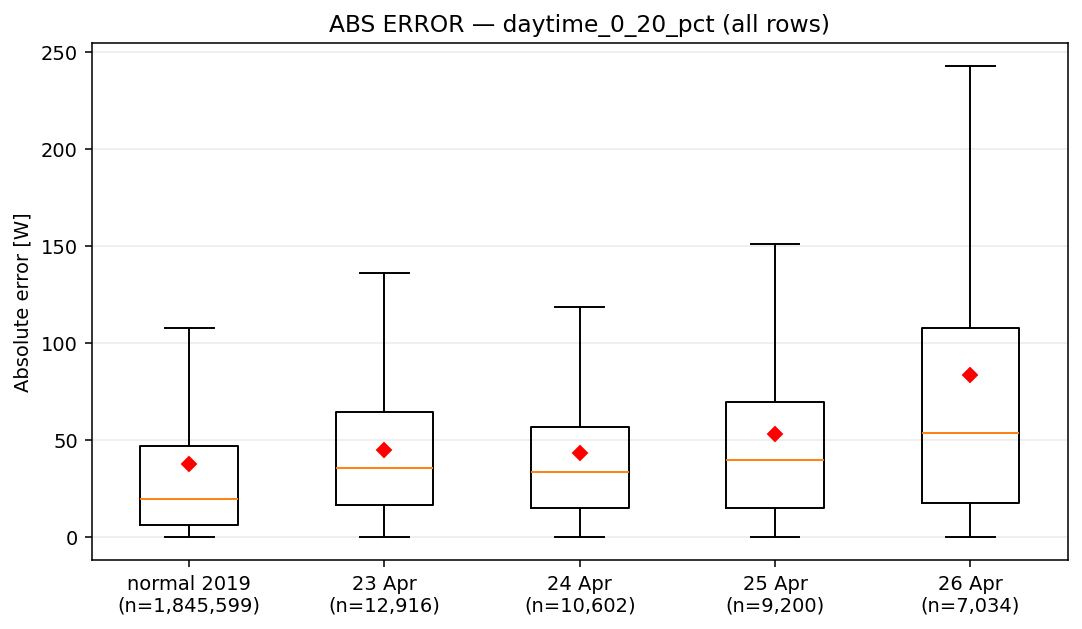

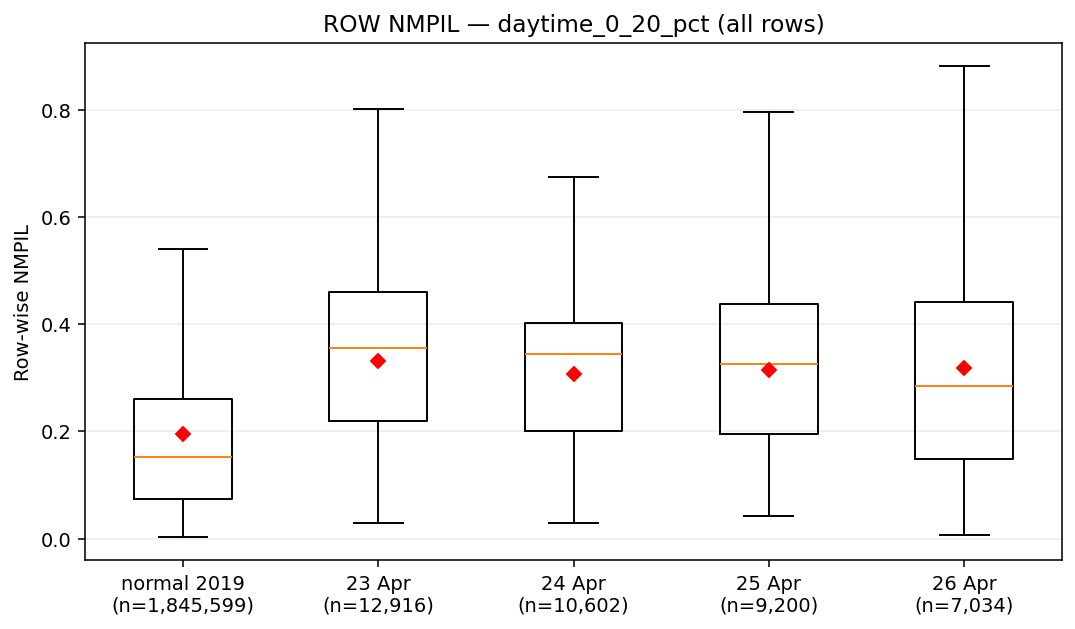

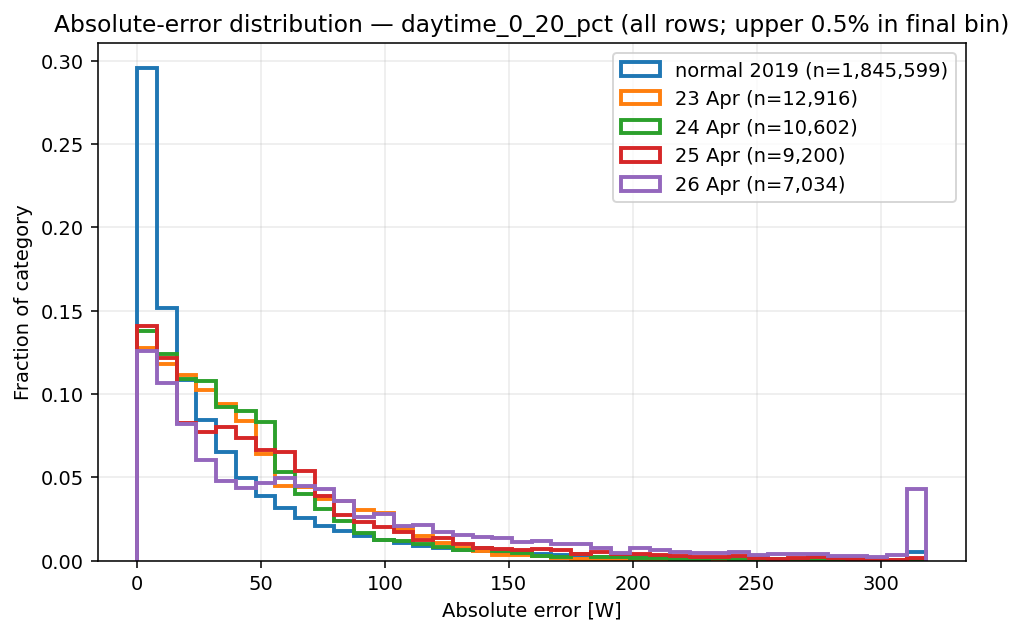

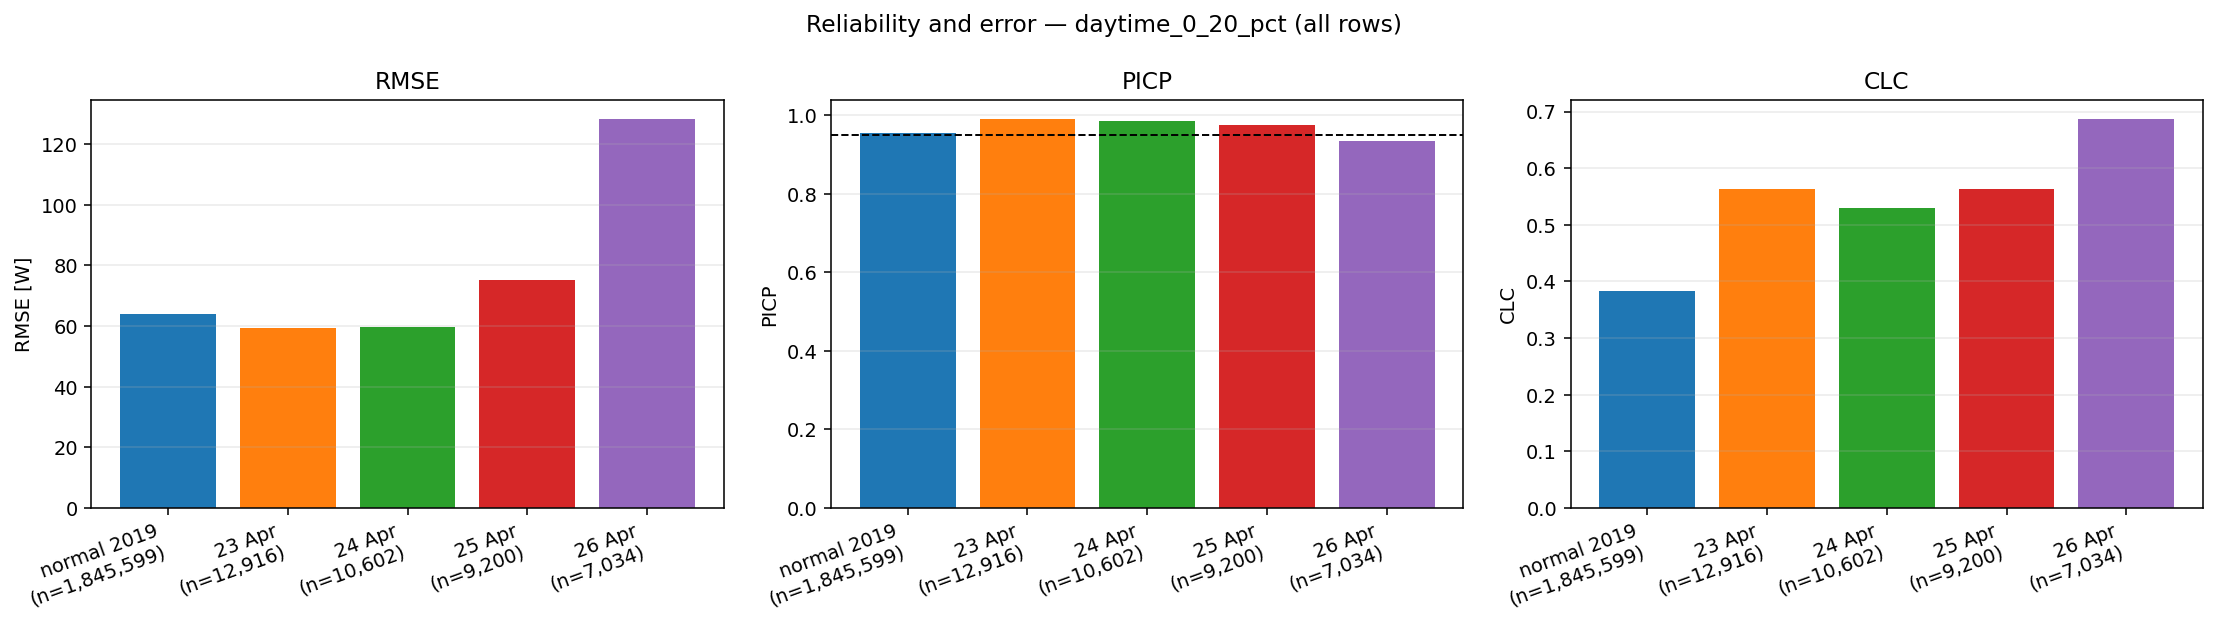

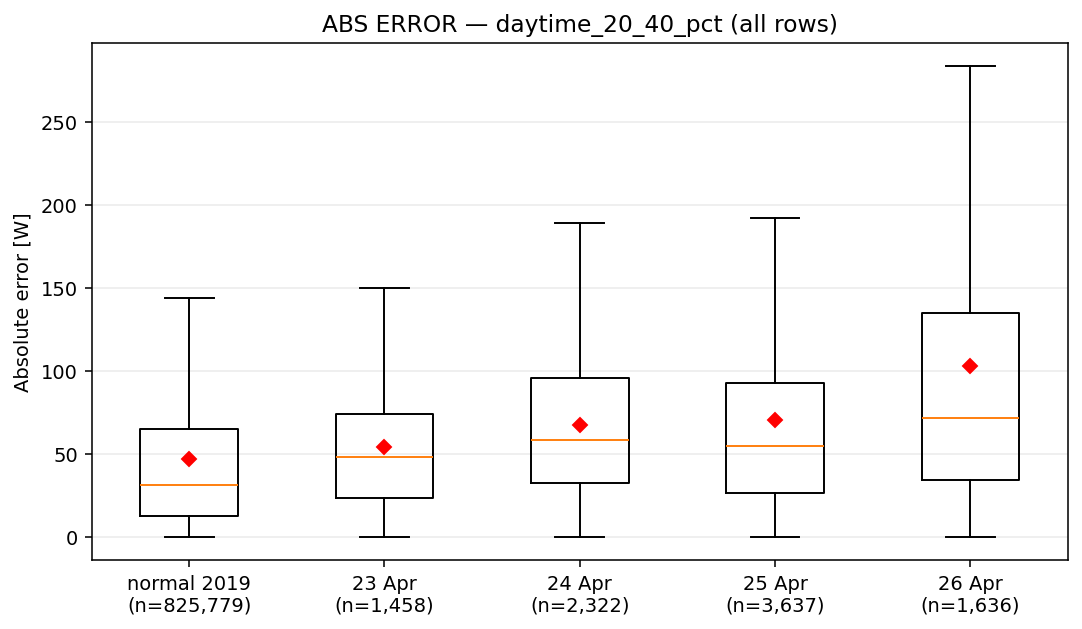

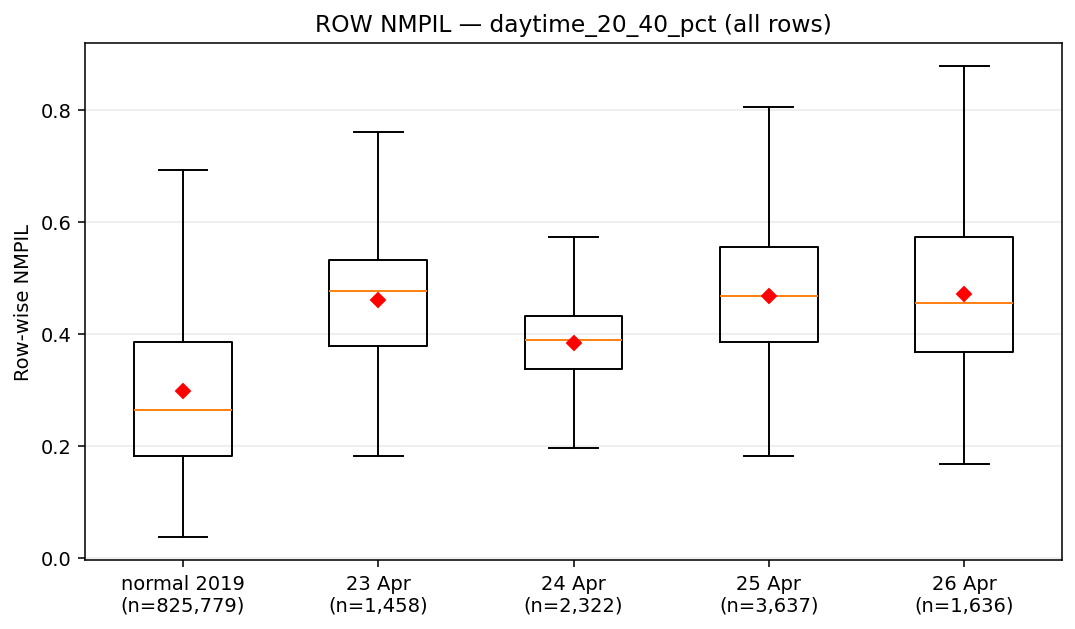

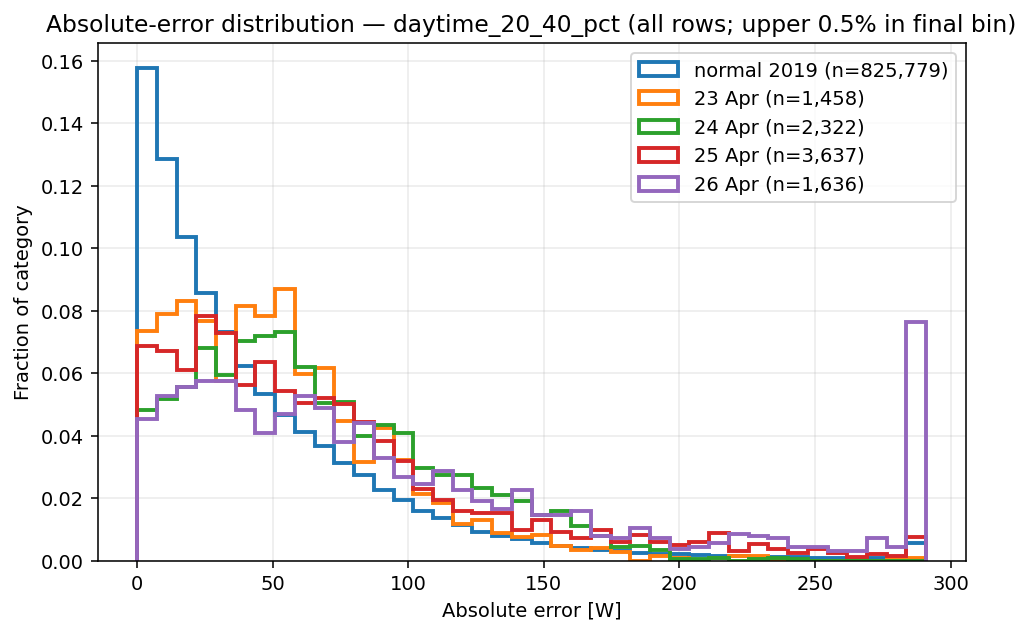

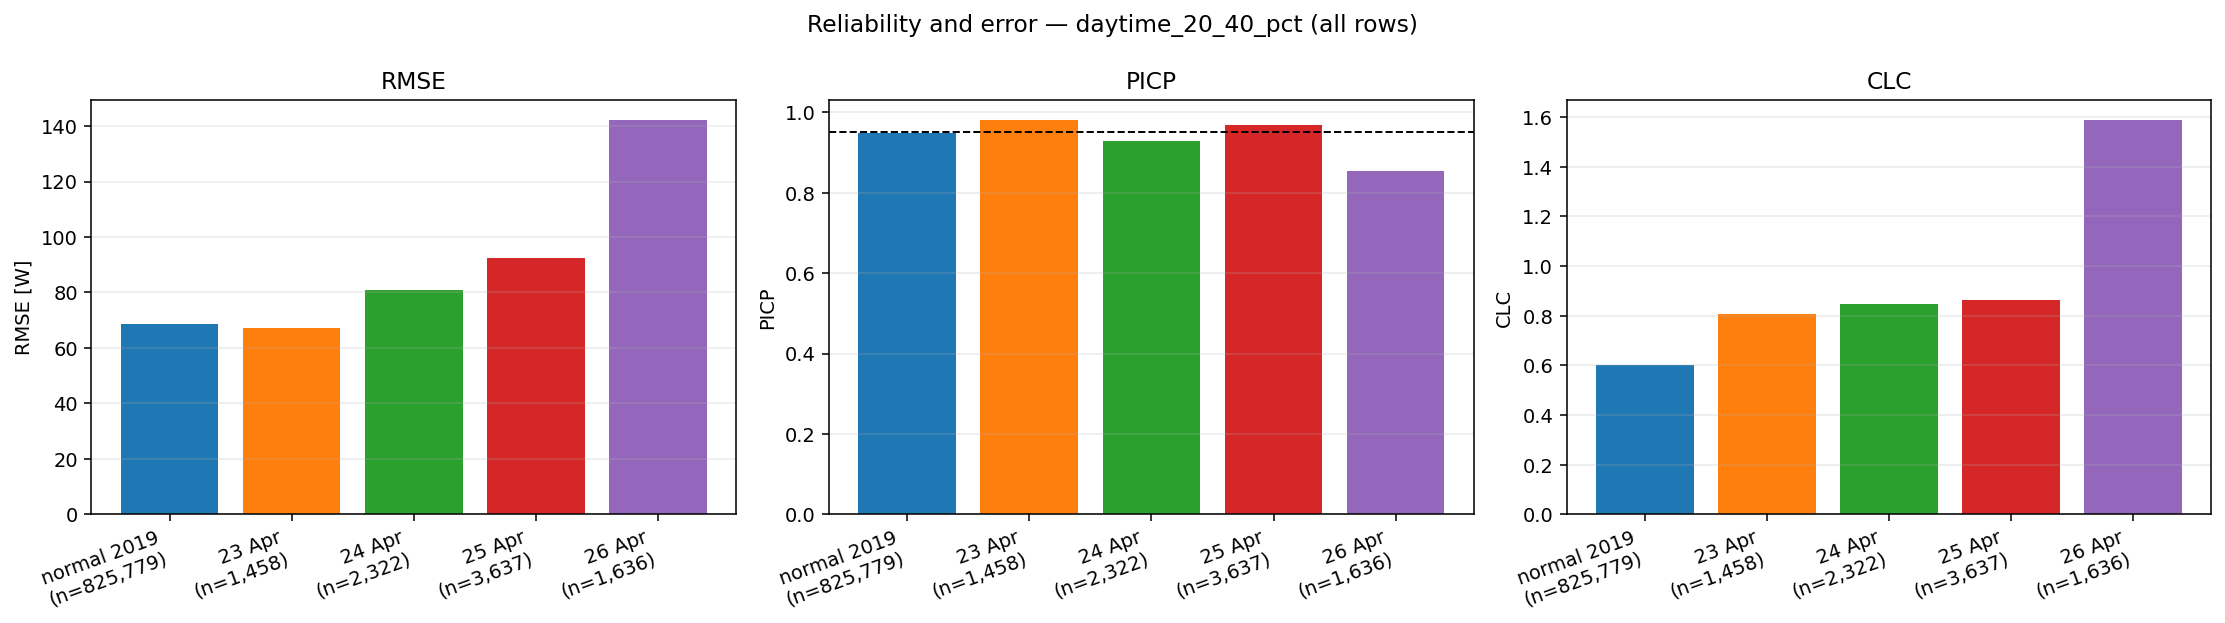

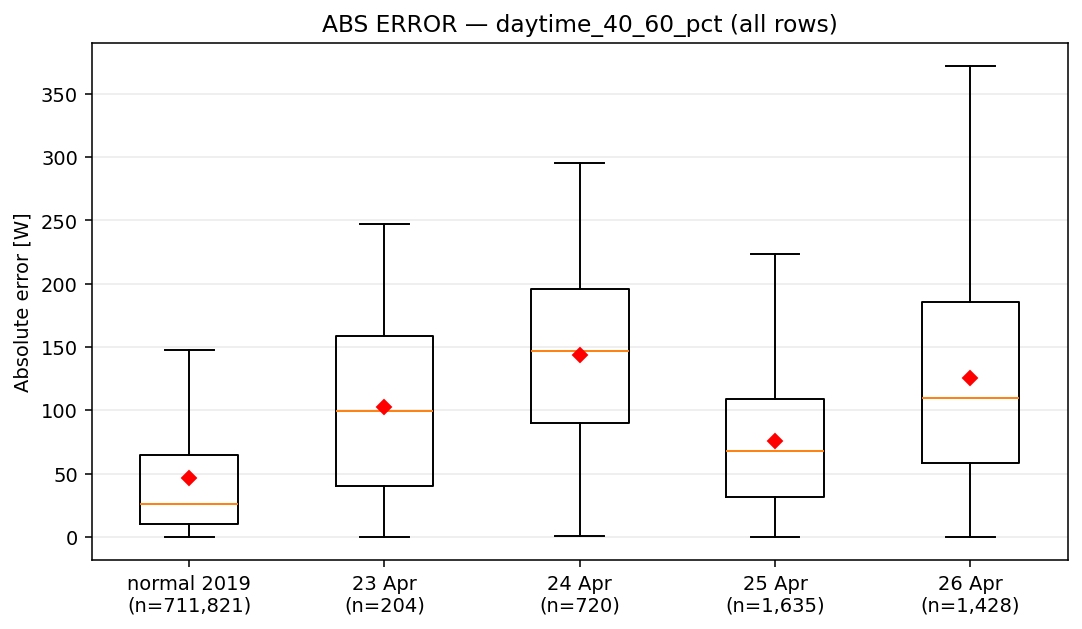

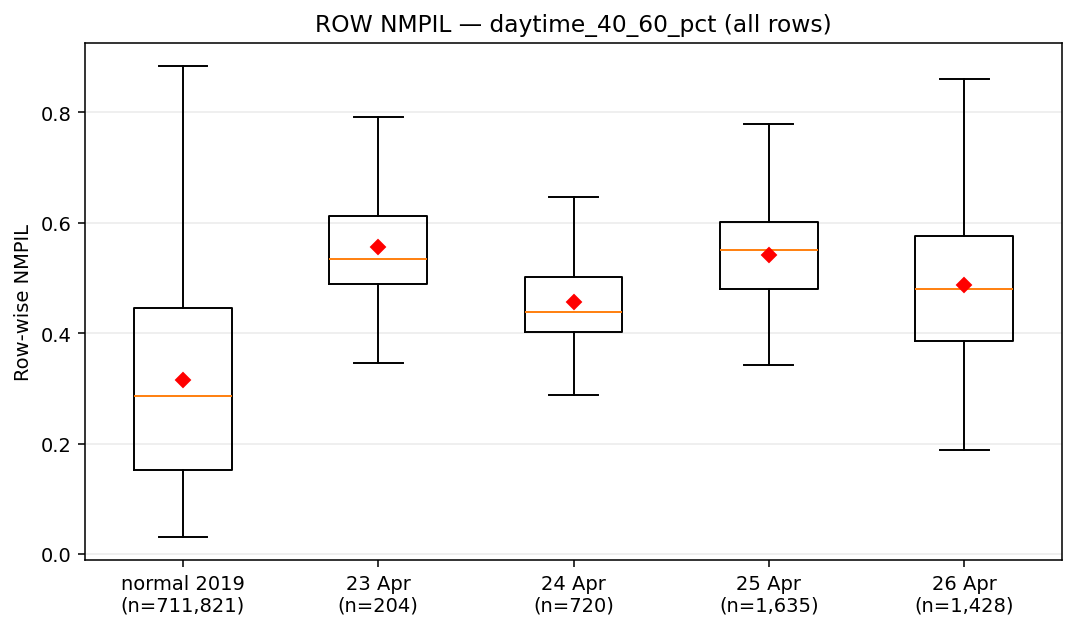

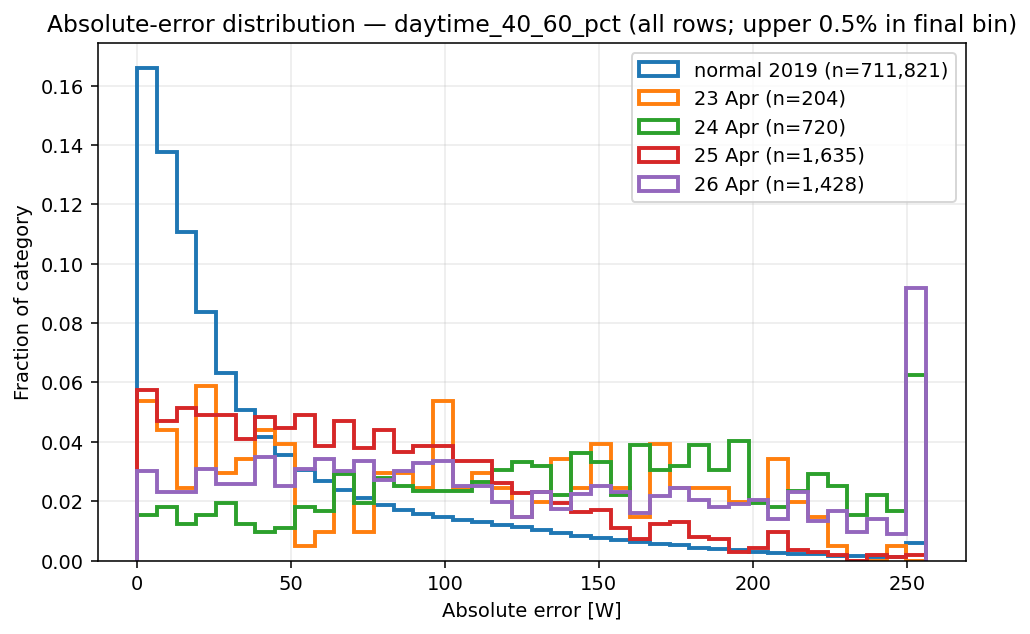

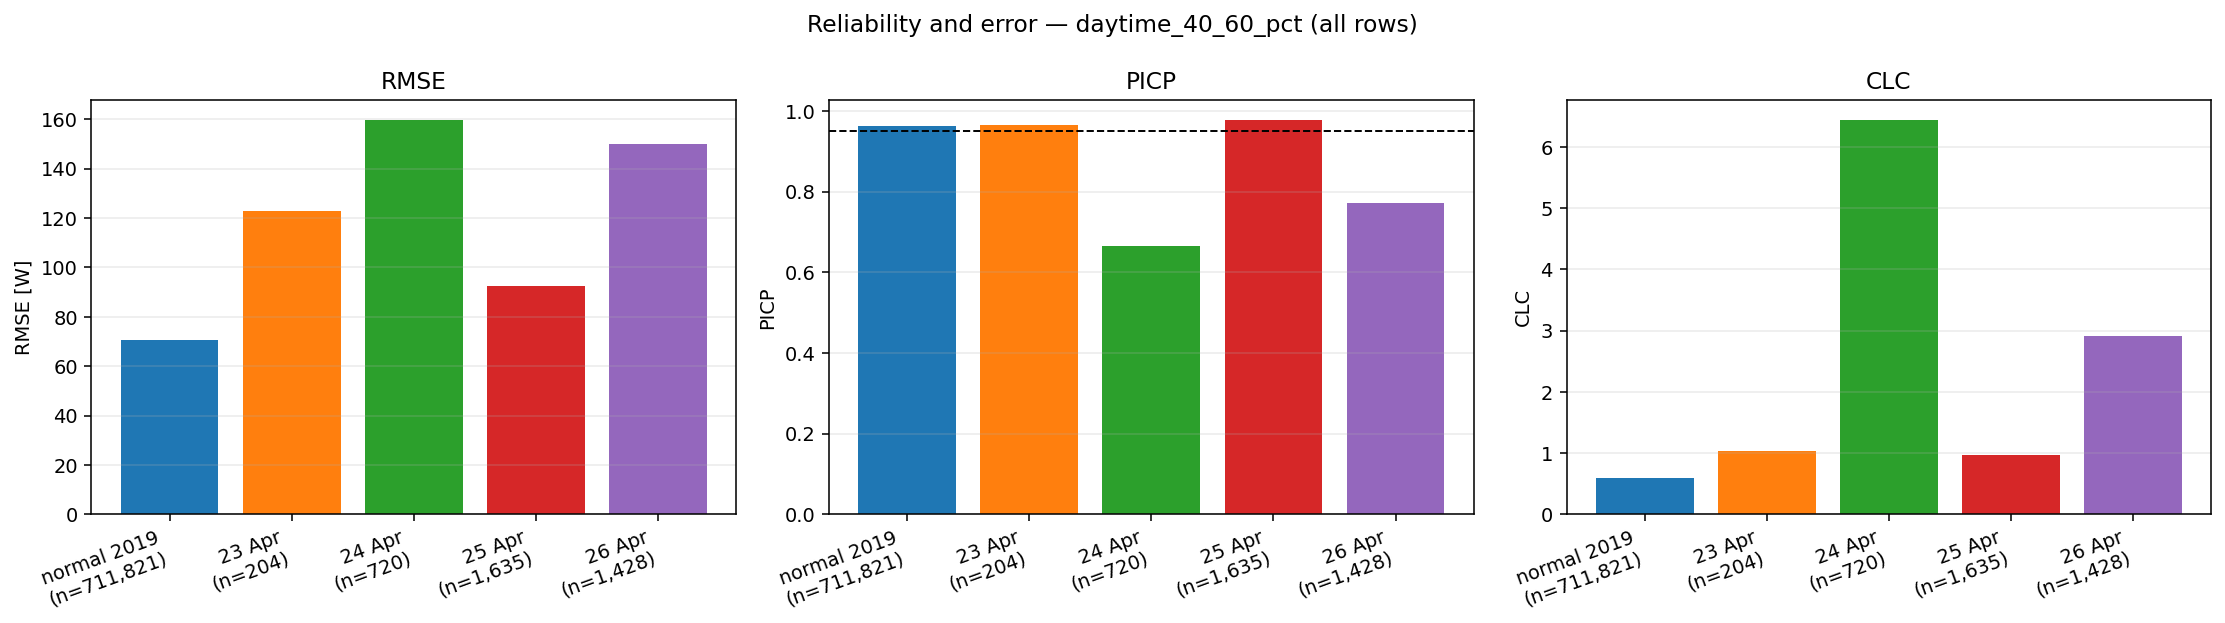

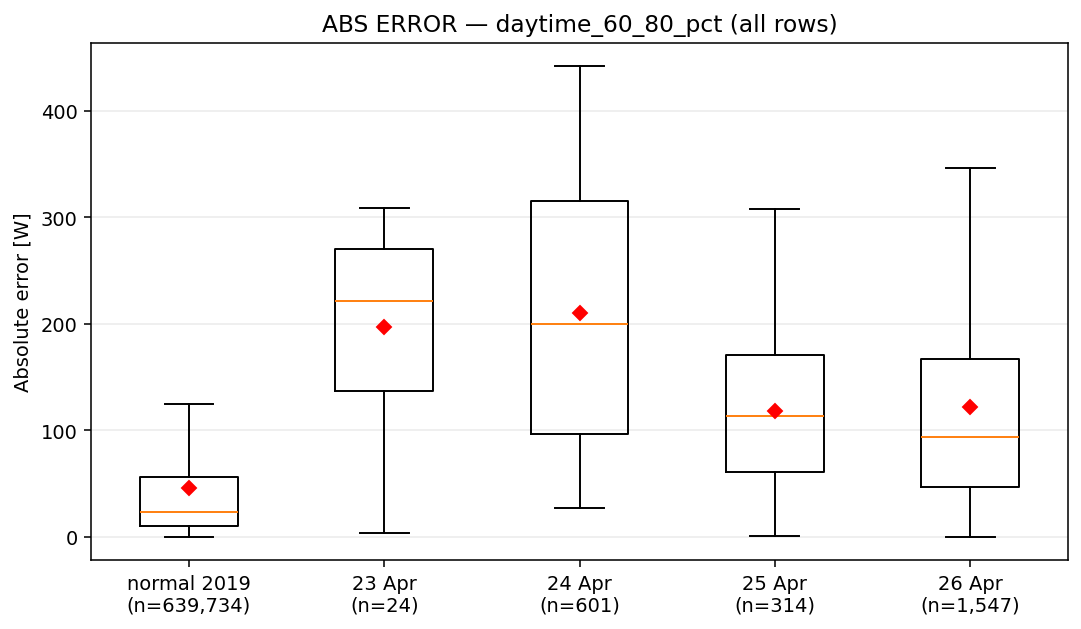

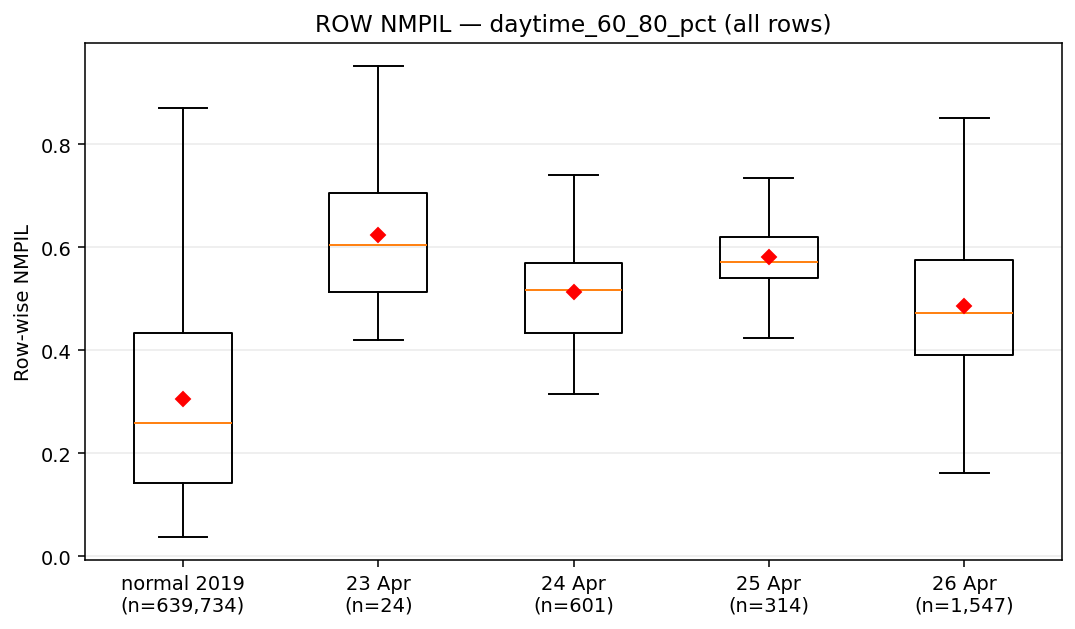

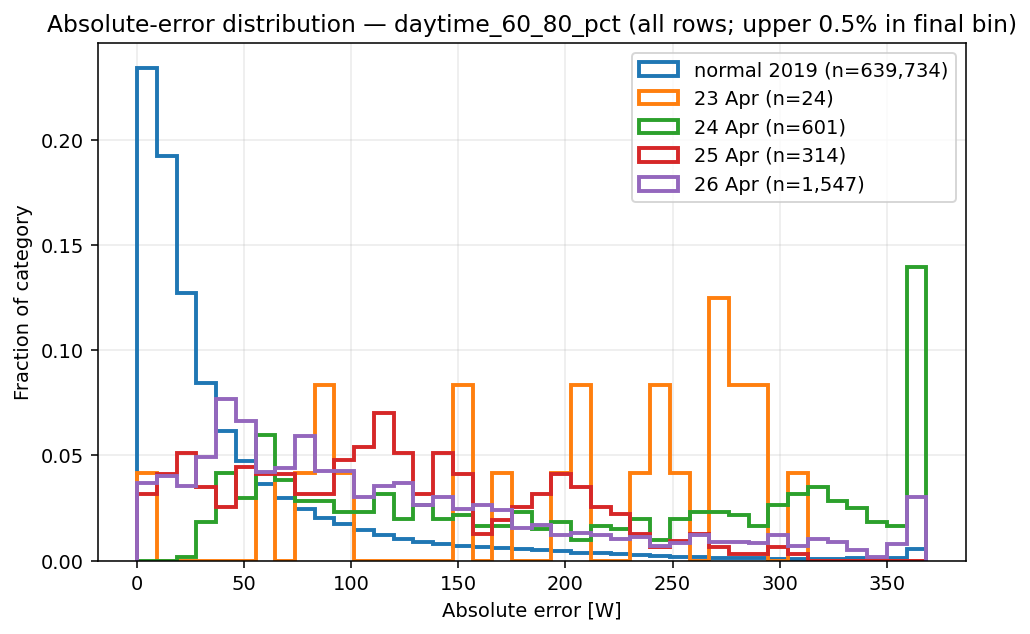

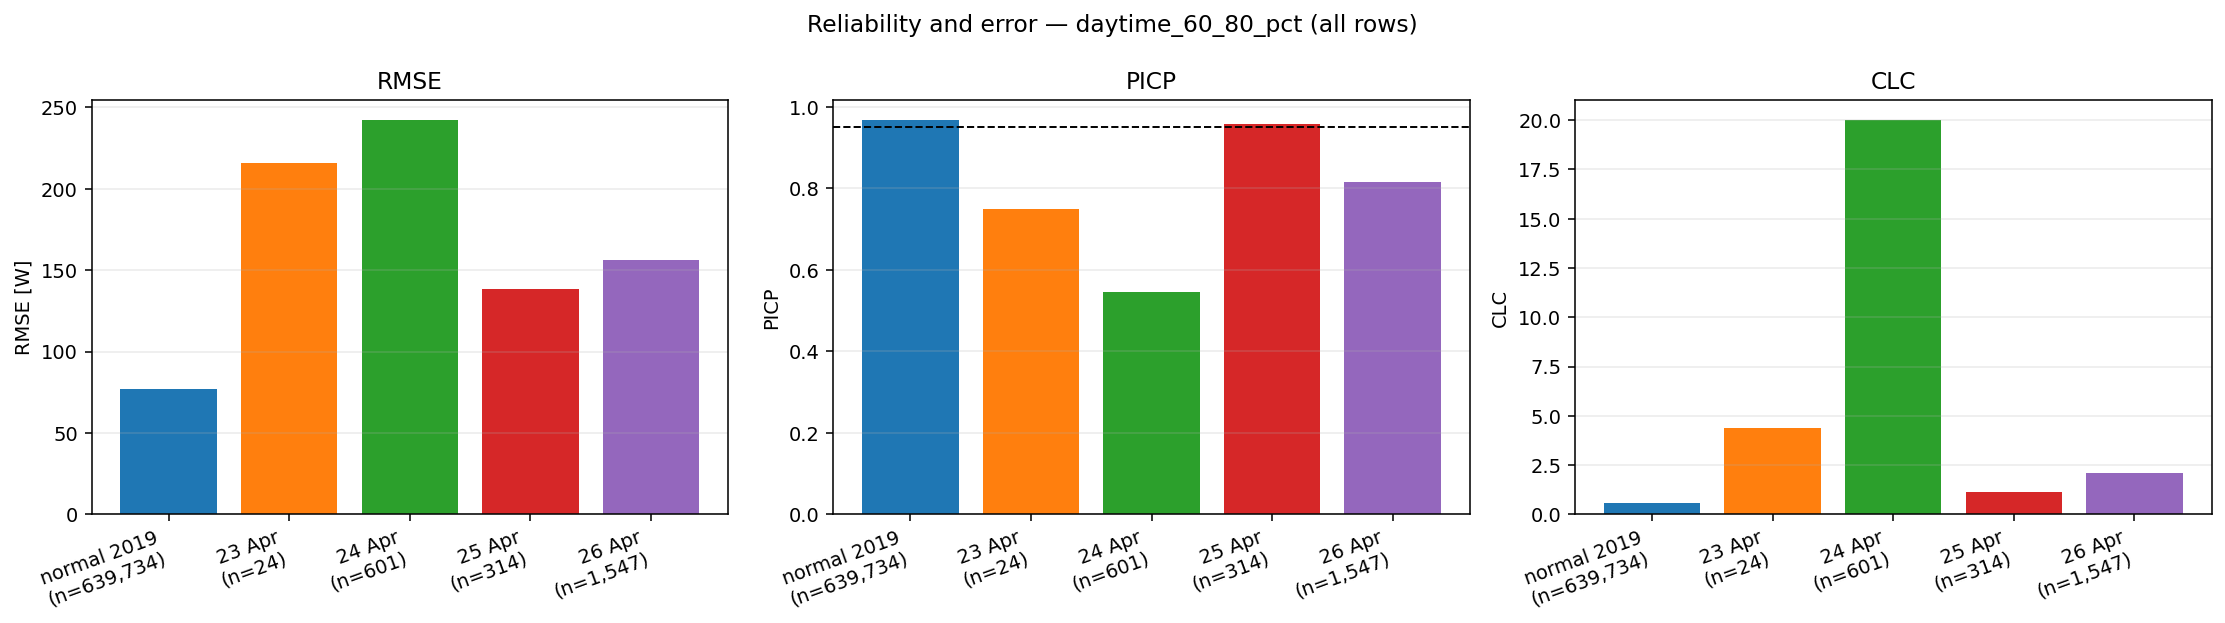

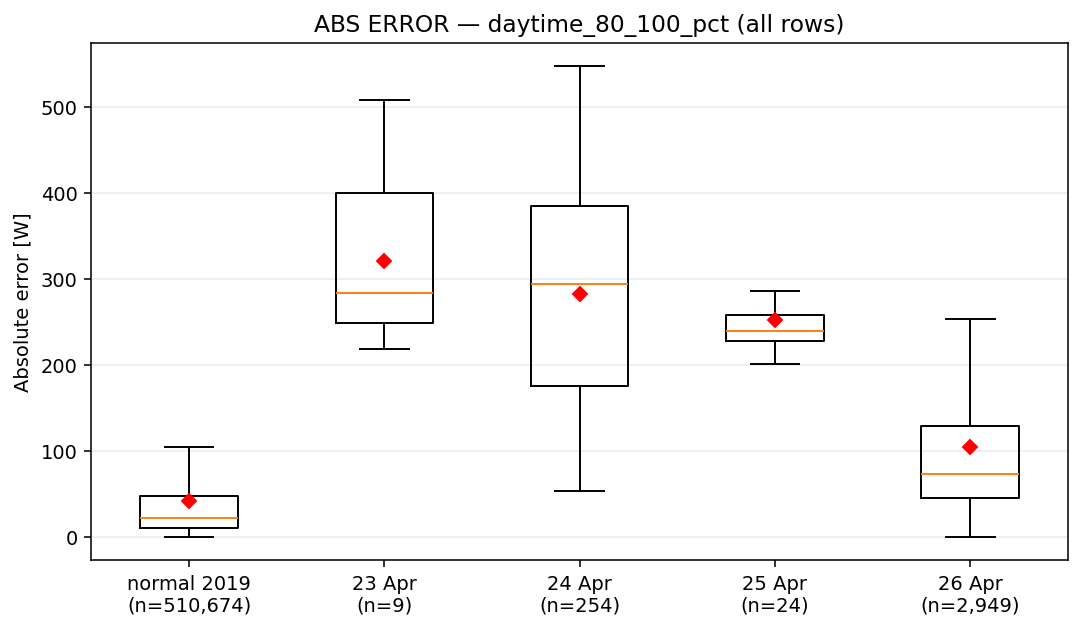

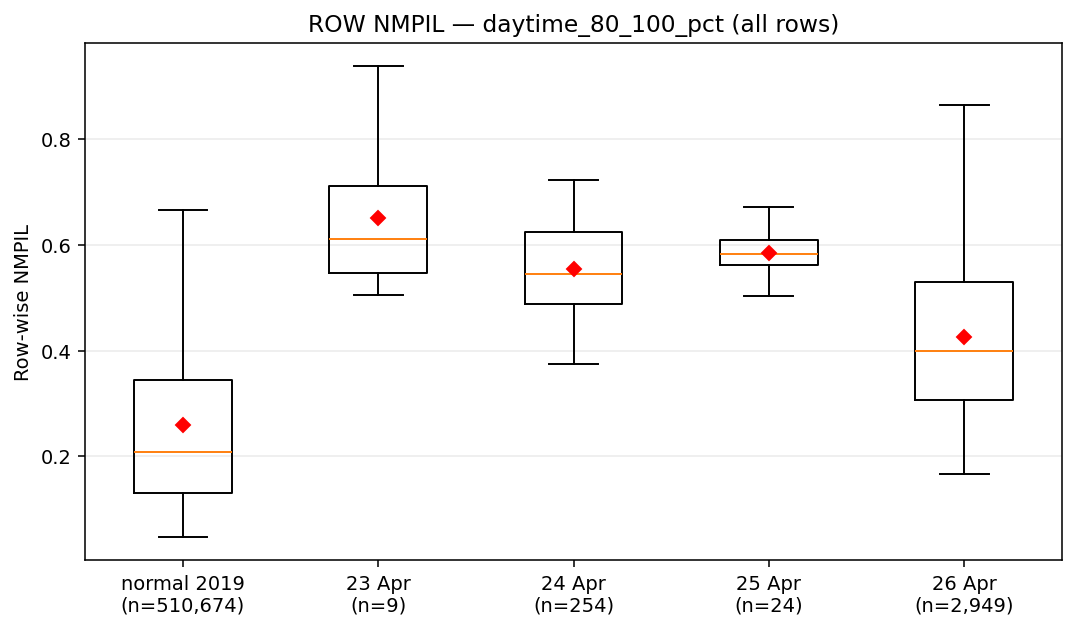

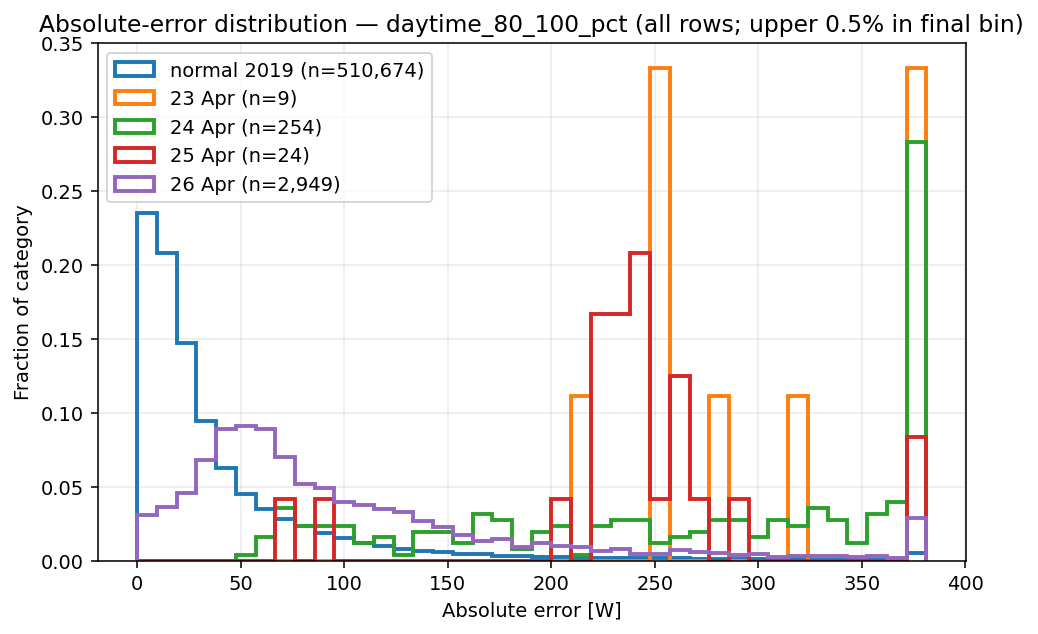

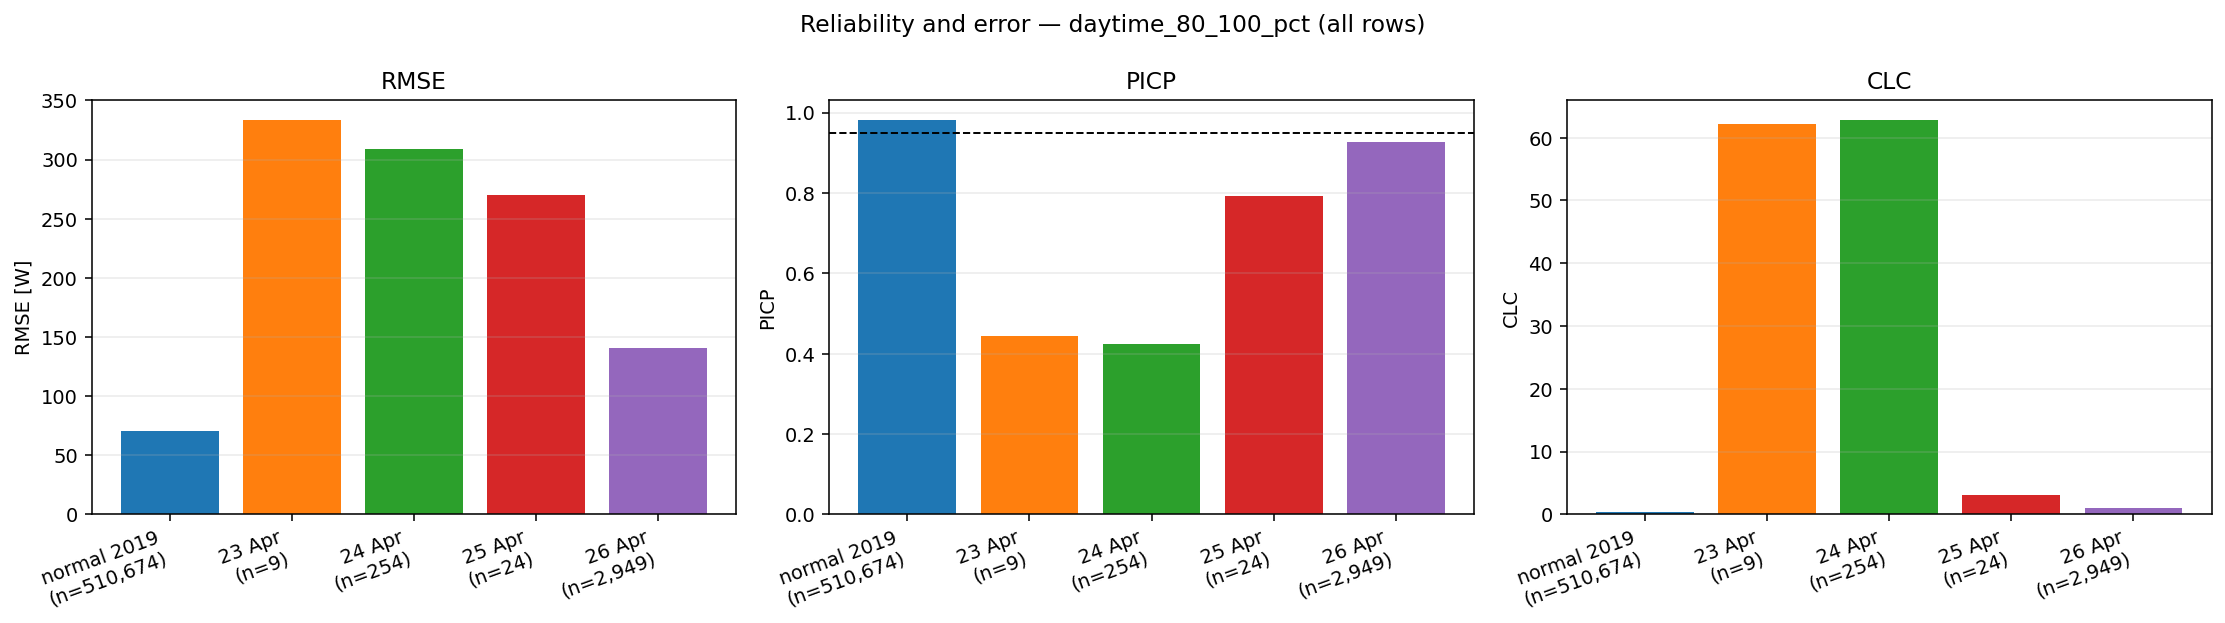

In [4]:
april_comparison = pipe.build_extreme_event_comparison_figures(
    str(out_dir),
    event_dates=(
        '2019-04-23',
        '2019-04-24',
        '2019-04-25',
        '2019-04-26',
    ),
    comparison_name='april_dust_23_26',
    figure_subdir='april_dust_event',
)

metrics = april_comparison['metrics']
display(metrics)
for metric in ('mae', 'rmse', 'picp', 'nmpil', 'clc'):
    print(f'\n=== {metric.upper()} ===')
    display(metrics.pivot(index='bin', columns='category', values=metric))

print('CSV metriche:', april_comparison['metrics_path'])
print('Grafici creati:', len(april_comparison['figure_paths']))
for figure_path in april_comparison['figure_paths'].values():
    display(Image(filename=str(figure_path)))

## 4. Lettura dei risultati

Controllare in particolare:

- se MAE e RMSE aumentano rispetto ai timestamp normali nelle stesse fasce di produzione;
- se il PICP resta vicino al 95% oppure crolla durante l'ingresso nell'evento;
- se l'aumento della banda è aleatorico o epistemico;
- se il 26 aprile resta raro ma torna facile da prevedere, indicando trascinamento della finestra MTGFlow più che difficoltà fisica persistente;
- se gli errori maggiori coincidono con il passaggio da irradiazione diretta a quasi interamente diffusa.